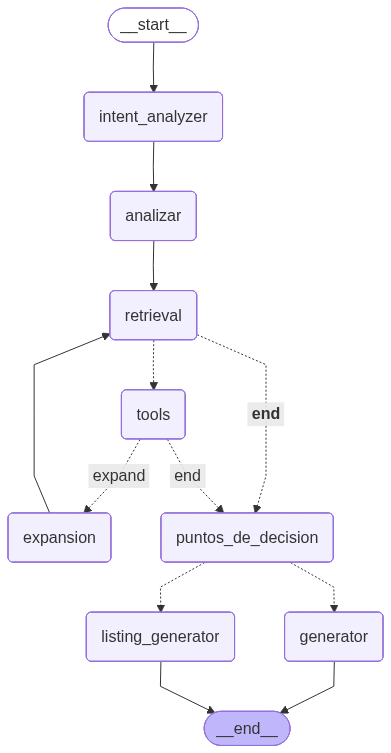

In [ ]:
from config import llm
from langchain_core.messages import SystemMessage, HumanMessage
from agent.graph import app
app

In [2]:
q = "Whats the last article about?"
q = "List me the last post related to Inteligencia Artificial"
# q="List me all post related to RAG"
# q="list articles or testing of 2024"
# # q = "what is amazon's revenue in 2024?"
q = "whats a vector store?"
# q = "Whats is the last article about?"
# q = "Last article about?"
# q = "Whats Retreival Augmnted Generation?"
# q = "whats the last article about?"
q = "Whats a Rag?"


q = "What is Bitovi's latest blog post about?"
q = "Can you show me all Bitovi articles about DevOps?"
# q = "How many articles does Bitovi have about AI?"
# q = "What kind of tools does Bitovi recommend for E2E testing?"



result = app.invoke({'messages': [HumanMessage(q)]})

result['messages'][-1].pretty_print()


--- [NODE] Clasificando Intención del Usuario ---
[INTENT] Type: TaskType.LISTING | Reason: The user wants to see a list of available resources or documents, blogs, articles, or posts. The goal is to retrieve the document containers.
--- [ANALYSIS] Analizando query: Can you show me all Bitovi articles about DevOps? ---
[ANALYSIS] Route: RetrievalRoute.CONVENCIONAL | Params: {'sort_by': None, 'top_k': 50}

[NODE] Query: Can you show me all Bitovi articles about DevOps?
[NODE] Strategic Route: RetrievalRoute.CONVENCIONAL
[NODE] Params from Analyzer: {'sort_by': None, 'top_k': 50}

[TOOL] retrieve_docs called for query: Bitovi articles about DevOps
--- [TOOL] Ejecutando búsqueda para ruta: RetrievalRoute.CONVENCIONAL ---
[TOOL] Usando parámetros del Analyzer -> Route: RetrievalRoute.CONVENCIONAL, Sort: None, TopK: 50
[TOOL] Filters: {'category': 'DevOps'}
[MODE] Convencional - Ranking Keywords: []
[MODE] Skipping Re-rank: No keywords found
[TOOL] Aplicando post-proceso: Sort by None, Lim

In [3]:
# q = "Whats a RAG?"
q = "whats the last article about?"

result = app.invoke({'messages': [HumanMessage(q)]})


--- [NODE] Clasificando Intención del Usuario ---
[INTENT] Type: TaskType.SINTESIS | Reason: The user wants to understand the topic of the last article, which is a content-based question.
--- [ANALYSIS] Analizando query: whats the last article about? ---
[ANALYSIS] Route: RetrievalRoute.FAST | Params: {'sort_by': 'date_ts', 'top_k': 1}

[NODE] Query: whats the last article about?
[NODE] Strategic Route: RetrievalRoute.FAST
[NODE] Params from Analyzer: {'sort_by': 'date_ts', 'top_k': 1}

[TOOL] retrieve_docs called for query: what is the last article about
--- [TOOL] Ejecutando búsqueda para ruta: RetrievalRoute.FAST ---
[TOOL] Usando parámetros del Analyzer -> Route: RetrievalRoute.FAST, Sort: date_ts, TopK: 1
[TOOL] Filters: {}
[MODE] Fast Retrieval - Skipping semantic
[TOOL] Aplicando post-proceso: Sort by date_ts, Limit 1

--- [NODE] Generando respuesta final ---


In [ ]:
qs= [
    "Whats the last article about?",
    "List me the last post related to Inteligencia Artificial",
    "List me all post related to RAG",
    "list articles or testing of 2024",
    "what is amazon's revenue in 2024?",
    "whats a vector store?",
    "Whats is the last article about?",
    "Last article about?",
    "Whats Retreival Augmnted Generation?",
    "whats the last article about?",
    "Whats a Rag?"
    ]


In [ ]:
for q in qs:
    apptest.invoke({'messages': [HumanMessage(q)]})


--- [NODE] Clasificando Intención del Usuario ---
[INTENT] Type: TaskType.SINTESIS | Reason: content_of
--- [ANALYSIS] Analizando query: Whats the last article about? ---
[ANALYSIS] Route: RetrievalRoute.FAST | Params: {'sort_by': 'date_ts', 'top_k': 1}

--- [NODE] Clasificando Intención del Usuario ---
[INTENT] Type: TaskType.LISTING | Reason: The user wants to know *what is in* the database, specifically looking for a recent article about AI.
--- [ANALYSIS] Analizando query: List me the last post related to Inteligencia Artificial ---
[ANALYSIS] Route: RetrievalRoute.CONVENCIONAL | Params: {'sort_by': 'date_ts', 'top_k': 1}

--- [NODE] Clasificando Intención del Usuario ---
[INTENT] Type: TaskType.LISTING | Reason: The user wants to know *what is in* the database.
--- [ANALYSIS] Analizando query: List me all post related to RAG ---
[ANALYSIS] Route: RetrievalRoute.CONVENCIONAL | Params: {'sort_by': None, 'top_k': 10}

--- [NODE] Clasificando Intención del Usuario ---
[INTENT] Type: 